<a href="https://colab.research.google.com/github/giministk/ml/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%967_%D0%9F%D1%80%D0%B8%D0%BC%D0%B5%D0%BD%D0%B5%D0%BD%D0%B8%D0%B5_%D0%BC%D0%B5%D1%82%D0%BE%D0%B4%D0%BE%D0%B2_%D0%BC%D0%B0%D1%88%D0%B8%D0%BD%D0%BD%D0%BE%D0%B3%D0%BE_%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D1%8F_%D0%B4%D0%BB%D1%8F_%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8_%D1%82%D0%B5%D0%BA%D1%81%D1%82%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №8. Применение методов машинного обучения для решения задач классификации текстов. Метод Наивного Байеса. Метод опорных векторов**

## Задание 0. Найдите в глобальной сети или соберите свой датасет для классификации текстов (Пример: новости -> рубрики, комментарии в соц. сетях -> характер, )

* Количество классов в датасете должно превышать 2
* Язык текста в датасете: русский

- ### Пример датасетов: [Russian Texts](https://www.kaggle.com/datasets?search=text+classification+russian)

### Загрузите датасет

In [ ]:
import kagglehub
import pandas as pd

kagglehub.dataset_download("blackmoon/russian-language-toxic-comments")
df = pd.read_csv('/kaggle/input/russian-language-toxic-comments/labeled.csv')

df.head()

Using Colab cache for faster access to the 'russian-language-toxic-comments' dataset.


,comment,toxic
0,"Верблюдов-то за что? Дебилы, бл...\n",1.0
1,"Хохлы, это отдушина затюканого россиянина, мол...",1.0
2,Собаке - собачья смерть\n,1.0
3,"Страницу обнови, дебил. Это тоже не оскорблени...",1.0
4,"тебя не убедил 6-страничный пдф в том, что Скр...",1.0


### Разделите данные на обучающую и валидационную выборки

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df['comment'], df['toxic'], test_size = 0.33, random_state = 42)
X_train.shape, X_test.shape

((9656,), (4756,))

### При выполении дальнейших заданий поэксперементируйте с методами векторизации текста:


1. [Bag of Words](https://habr.com/ru/companies/mlclass/articles/270591/) (BOW): Bag of Words представляет текст как вектор, где каждый элемент обозначает количество вхождений конкретного слова в тексте. Процесс включает в себя создание словаря всех уникальных слов в корпусе текстов и подсчет частоты встречаемости каждого слова в отдельных текстах.

2. [TF-IDF](https://habr.com/ru/companies/otus/articles/755772/) (Term Frequency-Inverse Document Frequency): TF-IDF учитывает не только количество вхождений слова в текст, но и частоту его встречаемости в других текстах. Он вычисляет вес слова, умножая его частоту встречаемости (term frequency) на обратную частоту документа (inverse document frequency). Это позволяет снизить вес наиболее часто встречающихся слов, которые могут быть менее информативными.

3. Word Embeddings (например, [Word2Vec](https://habr.com/ru/articles/446530/) и [GloVe](https://jonathan-hui.medium.com/nlp-word-embedding-glove-5e7f523999f6)): Word Embeddings используют нейронные сети для создания векторных представлений слов, которые учитывают семантическую близость между словами. Нейронные сети обучаются на больших текстовых корпусах и захватывают семантические отношения между словами, что позволяет представить слова в векторном пространстве.

4. One-Hot Encoding: One-Hot Encoding преобразует каждое слово в уникальный вектор, где все элементы равны нулю, за исключением одного, который равен единице. Каждый вектор соответствует отдельному слову и используется для представления его в пространстве признаков.

5. [Count Vectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html): Count Vectorizer подсчитывает количество раз, которое каждое слово встречается в тексте. Он создает вектор, в котором каждый элемент соответствует количеству вхождений конкретного слова в текст.

6. [Hashing Vectorizer](https://kavita-ganesan.com/hashingvectorizer-vs-countvectorizer/): Hashing Vectorizer преобразует каждое слово в уникальный числовой идентификатор с помощью хеширования. Он использует хеш-функцию для преобразования слова в числовое значение, которое затем используется в векторном представлении.

7. [Doc2Vec](https://habr.com/ru/articles/599513/): Doc2Vec является расширением метода Word2Vec и позволяет получить векторное представление не только отдельных слов, но и целых документов или текстов. Алгоритм обучает нейронную сеть, которая учитывает контекст и порядок слов в предложении, чтобы получить векторное представление документа. Это позволяет сравнивать и измерять семантическую близость между целыми текстовыми документами.

#### Оцените влияние разных методов на конечный результат

## Задание 1. Обучите модель классификатора Naive Bayes для решения поставленной задачи, используя пайплайн и подбор оптимальных параметров

In [ ]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('classifier', MultinomialNB())
])

param_grid = {
    'vectorizer__ngram_range': [(1, 1), (1, 2)],
    'classifier__alpha': [float(i) for i in np.linspace(start=0.01, stop=10.0, num=20)]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5)

grid_search.fit(X_train, y_train)

print(f'Лучшие параметры: {grid_search.best_params_}')

Лучшие параметры: {'classifier__alpha': 0.5357894736842106, 'vectorizer__ngram_range': (1, 1)}


### Вывод матрицы ошибок:

<Axes: >

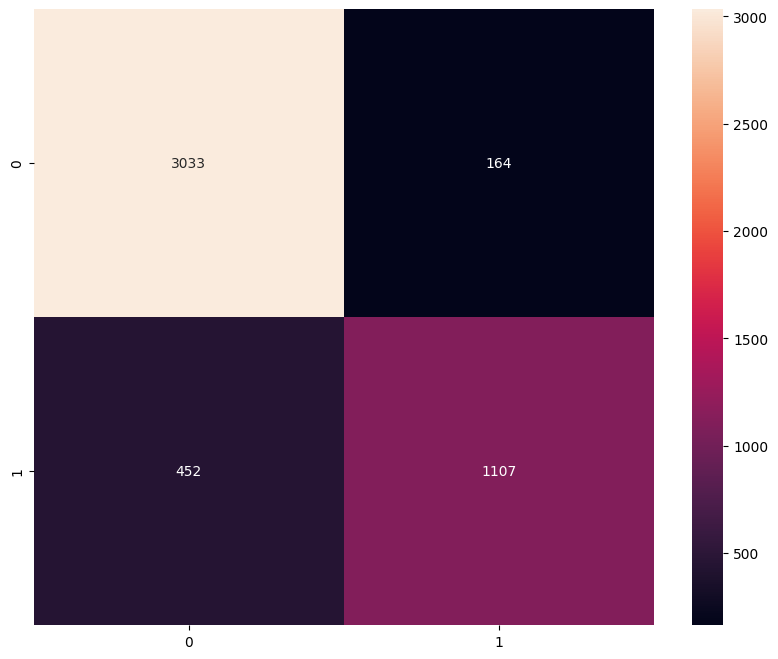

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

y_pred = grid_search.best_estimator_.predict(X_test)

conf_mat_NB=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(conf_mat_NB,annot=True,fmt='d')

### Оценка точности:

In [ ]:
from sklearn.metrics import accuracy_score

naive_acc=accuracy_score(y_test,y_pred)
naive_acc

0.8704793944491169

## Задание 2. Обучите модель SVM (метод опорных векторов) для решения поставленной задачи, используя пайплайны и подбор оптимальных параметров

In [ ]:
from sklearn.svm import SVC
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('svm', SVC(random_state=42))
])

param_grid = {
    'svm__C': [float(i) for i in np.linspace(start=0.1, stop=3.0, num=5)],
    'svm__gamma': ["scale", "auto", [float(i) for i in np.linspace(start=0.1, stop=3.0, num=3)]]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=4, verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f'Лучшие параметры: {grid_search.best_params_}')

Fitting 4 folds for each of 15 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
20 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **la

Лучшие параметры: {'svm__C': 3.0, 'svm__gamma': 'scale'}


### Вывод матрицы ошибок:

<Axes: >

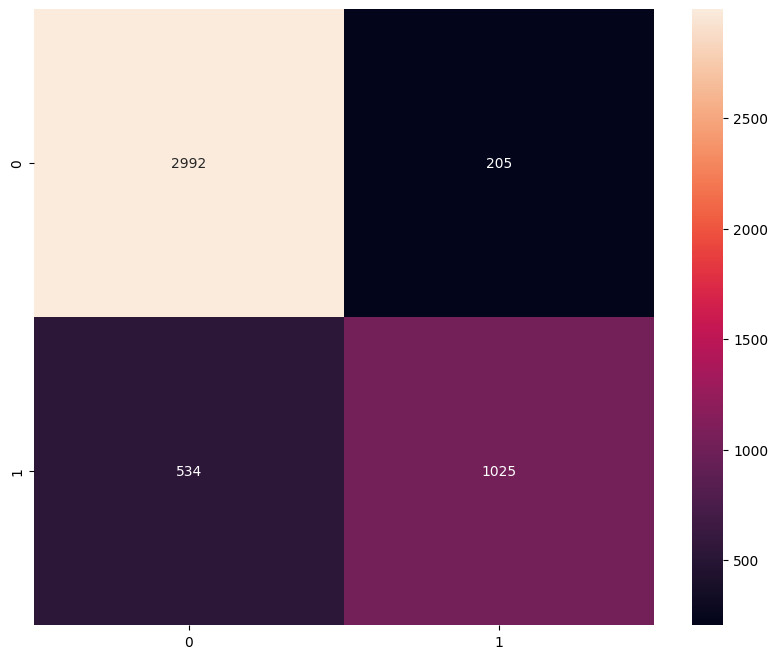

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

y_pred = grid_search.best_estimator_.predict(X_test)

conf_mat_NB=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(conf_mat_NB,annot=True,fmt='d')

### Оценка точности:

In [ ]:
from sklearn.metrics import accuracy_score

svm_acc=accuracy_score(y_test,y_pred)
svm_acc

0.8446173254835997

## Задание 3. Обучите модель классификатора Decision Tree Classifier для решения поставленной задачи

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

max_depth = [int(i) for i in np.linspace(start=1, stop=80, num=8)]
max_depth.append(None)
param_grid = {
    'classifier__max_leaf_nodes': [int(i) for i in np.linspace(start=2, stop=50, num=8)],
    'classifier__min_samples_split': [int(i) for i in np.linspace(start=2, stop=50, num=8)],
    'classifier__max_depth': max_depth
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

dec_tree = grid_search.best_estimator_

Fitting 5 folds for each of 576 candidates, totalling 2880 fits


### Вывод матрицы ошибок:

<Axes: >

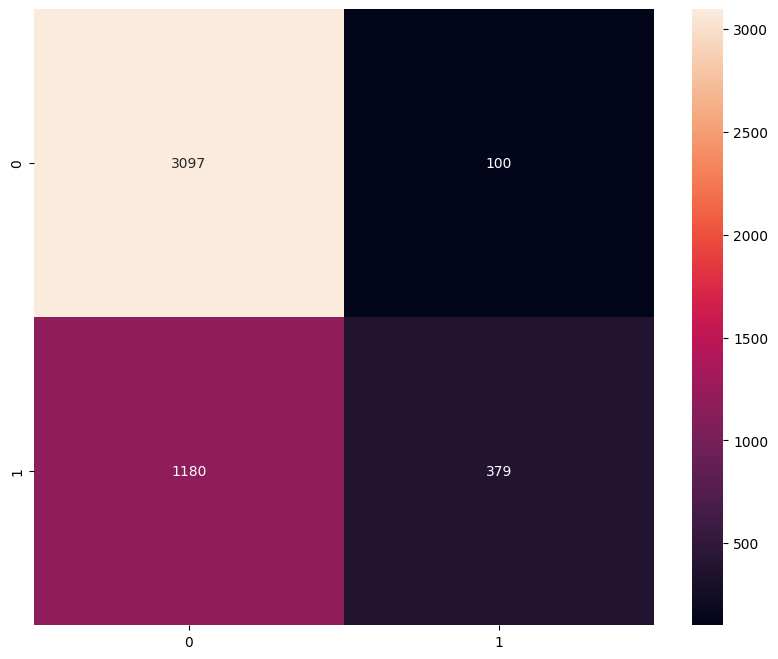

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

y_pred = dec_tree.predict(X_test)

conf_mat_NB=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(conf_mat_NB,annot=True,fmt='d')

### Оценка точности:

In [ ]:
from sklearn.metrics import accuracy_score

dec_acc=accuracy_score(y_test,y_pred)
dec_acc

0.7308662741799832

## Задание 4. Обучите модель классификатора Random Forest Classifier для решения поставленной задачи

In [ ]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('classifier', RandomForestClassifier(random_state=42))
])

max_depth = [int(i) for i in np.linspace(start=1, stop=80, num=5)]
max_depth.append(None)
param_grid = {
    'classifier__n_estimators': [int(x) for x in np.linspace(start=10, stop=300, num=5)],
    'classifier__max_depth': max_depth
}

gsearch = GridSearchCV(pipeline, param_grid, cv=4, verbose=1, n_jobs=-1)
gsearch.fit(X_train, y_train)

rand_f = gsearch.best_estimator_

Fitting 4 folds for each of 30 candidates, totalling 120 fits


### Вывод матрицы ошибок:

<Axes: >

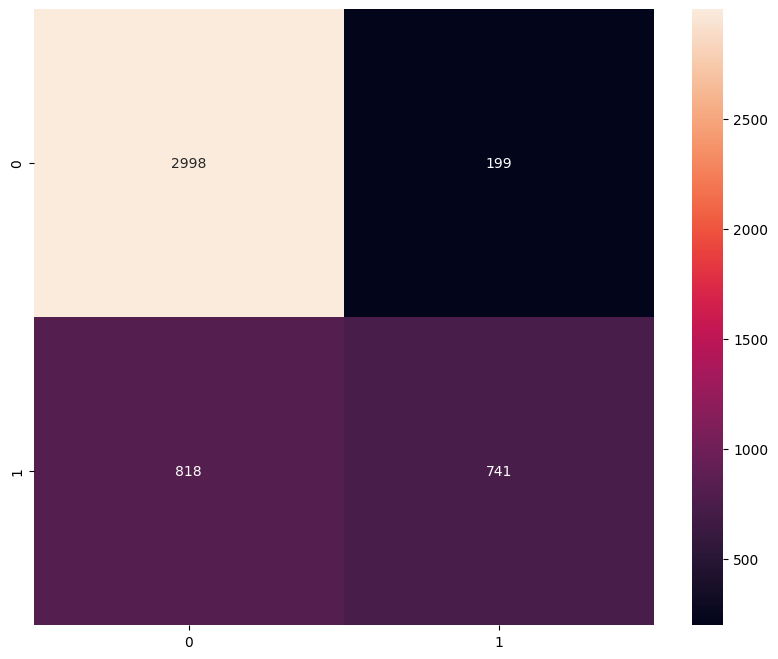

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

y_pred = rand_f.predict(X_test)
conf_mat_NB=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(conf_mat_NB,annot=True,fmt='d')

### Оценка точности:

In [ ]:
from sklearn.metrics import accuracy_score

rand_acc=accuracy_score(y_test,y_pred)
rand_acc

0.7861648444070648

## Подведите общие итоги и сделайте выводы

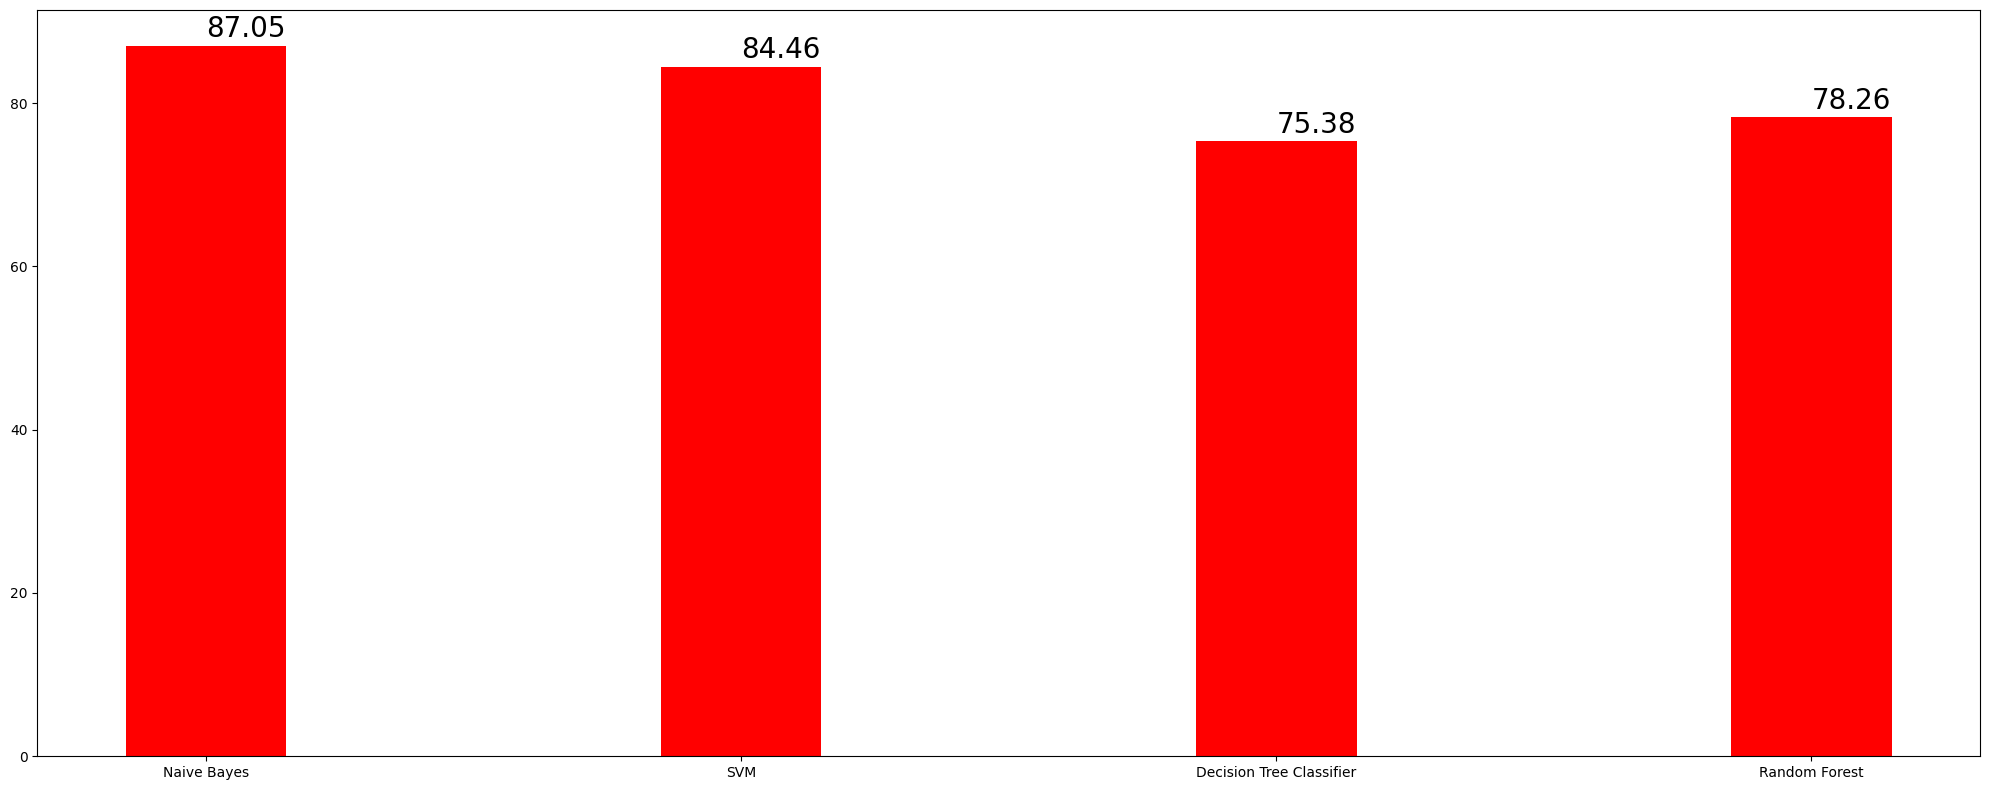

In [ ]:
menMeans = np.array([naive_acc,svm_acc, dec_acc, rand_acc])*100
ind = ['Naive Bayes','SVM','Decision Tree Classifier','Random Forest']
fig, ax = plt.subplots(figsize = (20,8))
ax.bar(ind,menMeans,width=0.3,color ='red')
for index,data in enumerate(menMeans):
    plt.text(x=index , y =data+1 , s="{:.2f}".format(data) , fontdict=dict(fontsize=20))
plt.tight_layout()
plt.show()

Лучше всего себя показал **наивный Байес**
